## 1. Setup & Data Check

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [22]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [23]:
df.shape

(7043, 21)

In [24]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [25]:
print("Duplicate rows:", df.duplicated().sum())
print("Missing values per column:\n", df.isnull().sum())
df.describe(include='all')

Duplicate rows: 0
Missing values per column:
 customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


**What we found:**
- 7,043 rows, 21 columns. No duplicate rows.
- TotalCharges is stored as text instead of a number which is the wrong data type.
- 11 rows have a blank string instead of a number.

In [26]:
blank_rows = df[df['TotalCharges'] == ' ']
blank_rows[['customerID','tenure','MonthlyCharges','TotalCharges']]

,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,
753,3115-CZMZD,0,20.25,
936,5709-LVOEQ,0,80.85,
1082,4367-NUYAO,0,25.75,
1340,1371-DWPAZ,0,56.05,
3331,7644-OMVMY,0,19.85,
3826,3213-VVOLG,0,25.35,
4380,2520-SGTTA,0,20.00,
5218,2923-ARZLG,0,19.70,
6670,4075-WKNIU,0,73.35,


**What we changed:**
1. All 11 blank TotalCharges rows have tenure = 0 meaning that these are new customers who have not been billed yet. We set TotalCharges = 0 for them and convert the column to numeric data type.
2. Converted SeniorCitizen from 0 and 1 to a readable No and Yes.
3. Confirmed all categorical columns have clean, consistent category names.

In [27]:
df['TotalCharges'] = df['TotalCharges'].replace(' ', 0)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

df['SeniorCitizen Label'] = df['SeniorCitizen'].map({0:'No', 1:'Yes'})

print("TotalCharges dtype now:", df['TotalCharges'].dtype)
print("Missing after cleaning:", df.isnull().sum().sum())

TotalCharges dtype now: float64
Missing after cleaning: 0


## 2. Churn Analysis

### 2.1 Overall Churn

Total customers: 7043
Churned: 1869
Retained: 5174
Churn rate: 26.54%


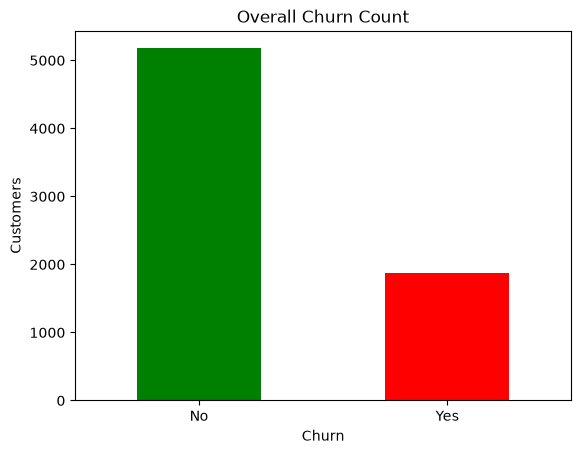

In [28]:
print(f"Total customers: {len(df)}")
print(f"Churned: {(df['Churn'] == 'Yes').sum()}")
print(f"Retained: {(df['Churn'] == 'No').sum()}")

churn_rate = (df['Churn'] == 'Yes').sum() / len(df) * 100
print(f"Churn rate: {churn_rate:.2f}%")

df['Churn'].value_counts().plot(kind='bar', color=('green', 'RED'))
plt.title('Overall Churn Count')
plt.ylabel('Customers')
plt.xticks(rotation=0)
plt.show()

**Interpretation:** About 1 in every 4 customers has churned, this is a high churn rate and retention deserves focused attention.

### 2.2 Churn by Contract

Churn              No    Yes
Contract                    
Month-to-month  57.29  42.71
One year        88.73  11.27
Two year        97.17   2.83


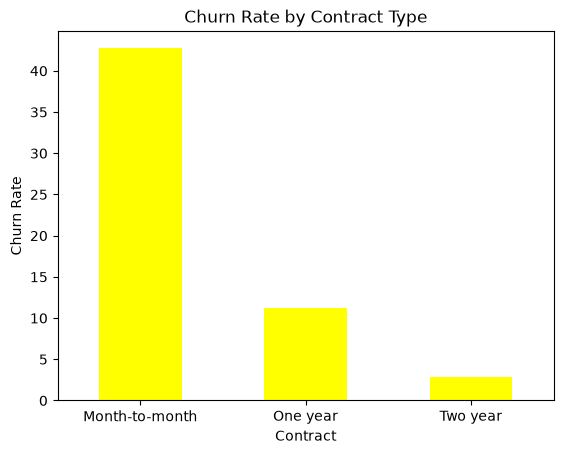

In [29]:
contract_churn = df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack() * 100
contract_churn = contract_churn.round(2)
print(contract_churn)

contract_churn['Yes'].sort_values(ascending=False).plot(kind='bar', color='yellow')
plt.title('Churn Rate by Contract Type')
plt.ylabel('Churn Rate')
plt.xticks(rotation=0)
plt.show()

**Interpretation:** Month-to-month contracts have the highest churn rate, much higher than one-year or two-year contracts meaning customers with no long term commitment leave far more easily.

### 2.3 Churn by Tenure

Churn           No    Yes
TenureGroup              
0-12         52.56  47.44
13-24        71.29  28.71
25-48        79.61  20.39
49+          90.49   9.51


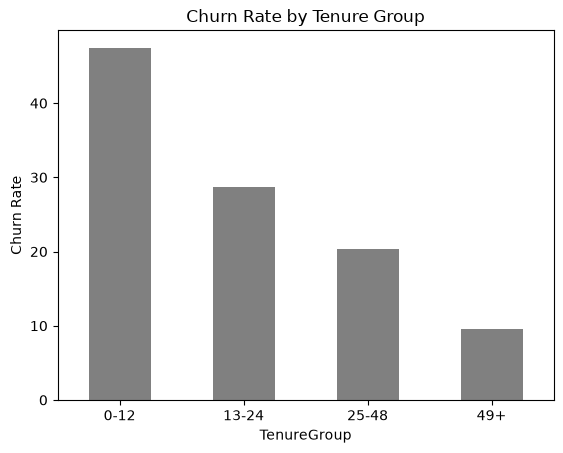

In [30]:
bins = [-1, 12, 24, 48, df['tenure'].max()]
labels = ['0-12', '13-24', '25-48', '49+']
df['TenureGroup'] = pd.cut(df['tenure'], bins=bins, labels=labels)

tenure_churn = df.groupby('TenureGroup', observed=True)['Churn'].value_counts(normalize=True).unstack() * 100
tenure_churn = tenure_churn.round(2)
print(tenure_churn)

tenure_churn['Yes'].plot(kind='bar', color='grey')
plt.title('Churn Rate by Tenure Group')
plt.ylabel('Churn Rate')
plt.xticks(rotation=0)
plt.show()

**Interpretation:** Customers in their 0-12 months churn the most. Risk drops the longer a customer stays, so the first year is very important.

### 2.4 Monthly Charges: Churned vs Retained

Churn
No     61.27
Yes    74.44
Name: MonthlyCharges, dtype: float64


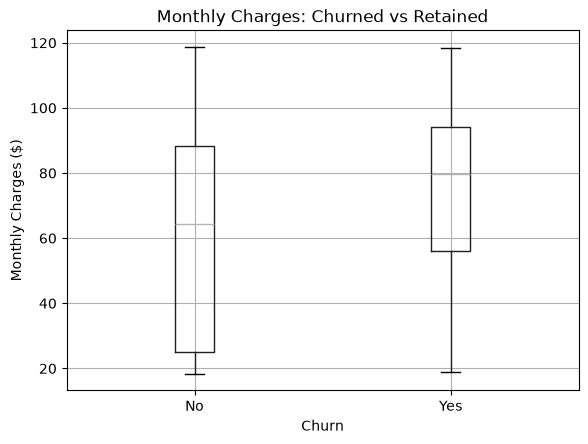

In [31]:
avg_charges = df.groupby('Churn')['MonthlyCharges'].mean().round(2)
print(avg_charges)

df.boxplot(column='MonthlyCharges', by='Churn')
plt.title('Monthly Charges: Churned vs Retained')
plt.suptitle('')
plt.ylabel('Monthly Charges ($)')
plt.show()

**Interpretation:** Customers who churned paid noticeably more per month on average than customers who stayed. Higher bills appear linked to a higher chance of leaving.

### 2.5 Churn by Payment Method

Churn                         No    Yes
PaymentMethod                          
Electronic check           54.71  45.29
Mailed check               80.89  19.11
Bank transfer (automatic)  83.29  16.71
Credit card (automatic)    84.76  15.24


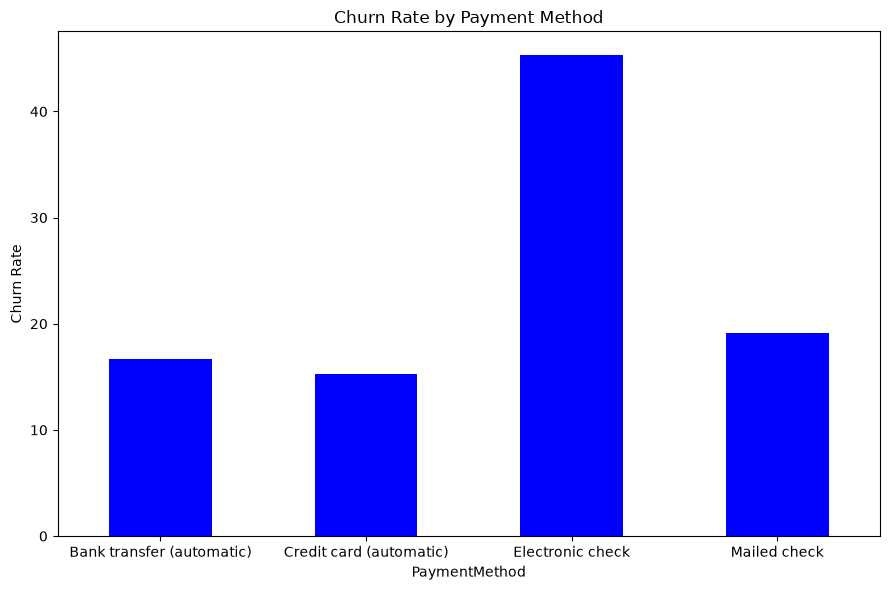

In [32]:
payment_churn = df.groupby('PaymentMethod')['Churn'].value_counts(normalize=True).unstack() * 100
print(payment_churn.round(2).sort_values('Yes', ascending=False))

payment_churn['Yes'].plot(kind='bar', figsize=(9, 6), color='blue')
plt.title('Churn Rate by Payment Method')
plt.ylabel('Churn Rate')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Interpretation:** Customers paying by electronic check churn far more than those on automatic payment methods. Manual payment may signal lower commitment or more failed payments.

### 2.6 Services

Churn rate by Internet Service:
 Churn               No    Yes
InternetService              
DSL              81.04  18.96
Fiber optic      58.11  41.89
No               92.60   7.40

Churn rate  by Tech Support:
 Churn                   No    Yes
TechSupport                      
No                   58.36  41.64
No internet service  92.60   7.40
Yes                  84.83  15.17


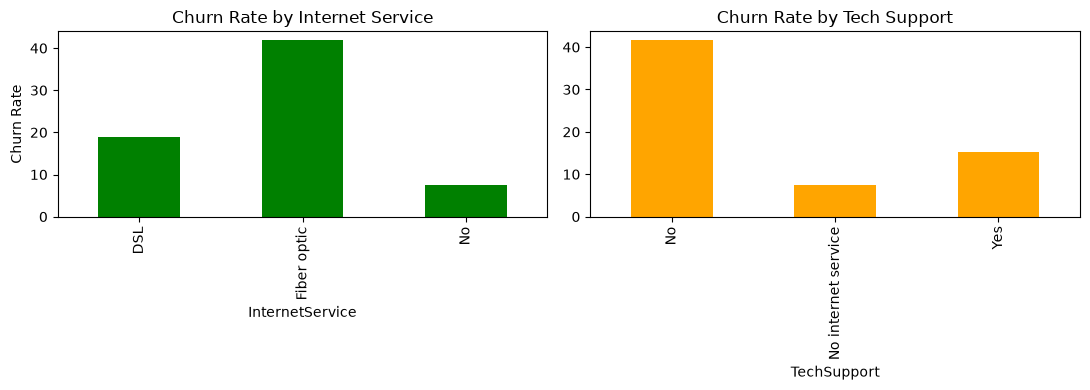

In [33]:
internet_churn = df.groupby('InternetService')['Churn'].value_counts(normalize=True).unstack() * 100
techsupport_churn = df.groupby('TechSupport')['Churn'].value_counts(normalize=True).unstack() * 100

print("Churn rate by Internet Service:\n", internet_churn.round(2))
print("\nChurn rate  by Tech Support:\n", techsupport_churn.round(2))

fig, axes = plt.subplots(1, 2, figsize=(11,4))
internet_churn['Yes'].plot(kind='bar', ax=axes[0], color='green')
axes[0].set_title('Churn Rate by Internet Service')
axes[0].set_ylabel('Churn Rate')
techsupport_churn['Yes'].plot(kind='bar', ax=axes[1], color='orange')
axes[1].set_title('Churn Rate by Tech Support')
plt.tight_layout()
plt.show()

**Interpretation:** Customers with Fiber optic internet churn much more than DSL or no internet customers possibly price or internet service quality related. Customers without Tech Support also churn far more than those who have it, suggesting support subscriptions help retention.

## 3. Statistical Analysis

### Test 1 — Contract vs Churn

In [34]:
contingency = pd.crosstab(df['Contract'], df['Churn'])
chi2, p_value, dof, expected = stats.chi2_contingency(contingency)

print(f"Chi-square statistic: {chi2:.2f}")
print(f"p-value: {p_value:.10f}")
print(f"Degrees of freedom: {dof}")

decision = "Reject H0" if p_value < 0.05 else "Fail to reject H0"
print(f"Decision (α=0.05): {decision}")

Chi-square statistic: 1184.60
p-value: 0.0000000000
Degrees of freedom: 2
Decision (α=0.05): Reject H0


**Interpretation:** p-value is far below 0.05, so we reject H0 meaning that Contract type and churn are statistically associated this confirms the pattern seen earlier that month-to-month customers churn significantly more than contracted customers.

### Test 2 — Monthly Charges vs Churn
Compares average monthly charges of churned vs retained customers.

In [35]:
churned_charges = df[df['Churn']=='Yes']['MonthlyCharges']
retained_charges = df[df['Churn']=='No']['MonthlyCharges']

t_stat, p_value_t = stats.ttest_ind(churned_charges, retained_charges, equal_var=False)

print(f"Average Churned: {churned_charges.mean():.2f}")
print(f"Average Retained: {retained_charges.mean():.2f}")
print(f"T-statistic: {t_stat:.2f}")
print(f"p-value: {p_value_t:.10f}")

decision_t = "Reject H0" if p_value_t < 0.05 else "Fail to reject H0"
print(f"Decision (α=0.05): {decision_t}")

Average Churned: 74.44
Average Retained: 61.27
T-statistic: 18.41
p-value: 0.0000000000
Decision (α=0.05): Reject H0


**Interpretation:** p-value is far below 0.05, so we reject H0 meaning the difference in monthly charges between churned and retained customers is statistically significant so churned customers pay significantly more on average.

## 4. Customer Segmentation & Revenue at Risk

In [36]:
median_charge = df['MonthlyCharges'].median()

def segment(row):
    if row['tenure'] <= 12:
        return 'New'
    if row['MonthlyCharges'] > median_charge and row['Contract'] == 'Month-to-month':
        return 'High-Risk'
    if row['MonthlyCharges'] > median_charge:
        return 'High-Value'
    return 'Loyal'

df['Segment'] = df.apply(segment, axis=1)

segment_summary = df.groupby('Segment').agg(
    Customers=('Segment','count'),
    Avg_Tenure=('tenure','mean'),
    Avg_MonthlyCharges=('MonthlyCharges','mean'),
    Churn_Rate_pct=('Churn', lambda x: (x=='Yes').mean()*100)
).round(2).sort_values('Churn_Rate_pct', ascending=False)

segment_summary

,Customers,Avg_Tenure,Avg_MonthlyCharges,Churn_Rate_pct
Segment,,,,
New,2186,4.73,56.10,47.44
High-Risk,1231,34.31,90.74,41.51
High-Value,1454,57.97,94.42,10.66
Loyal,2172,41.95,38.90,7.64


**Interpretation**: New customers churn the most often at 47.4% but they are cheap so losing one does not cost much. One the other hand High-Risk customers churn almost as much at 41.5% and since they pay $90.74 a month on average, every one of them who leaves is a massive lost. That means New customers need a better first year experience to build trust early on, while High-Risk customers need a retention before they leave for good.

In [37]:
revenue_at_risk = df[df['Churn']=='Yes']['MonthlyCharges'].sum()
print(f"Monthly Revenue at Risk: ${revenue_at_risk:,.2f}")
print(f"Annualized Revenue at Risk: ${revenue_at_risk*12:,.2f}")

Monthly Revenue at Risk: $139,130.85
Annualized Revenue at Risk: $1,669,570.20


## 5. Export Cleaned Data for Power BI

In [38]:
export_cols = ['customerID','gender','SeniorCitizen_Label','Partner','Dependents','tenure',
               'TenureGroup','PhoneService','MultipleLines','InternetService','OnlineSecurity',
               'OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies',
               'Contract','PaperlessBilling','PaymentMethod','MonthlyCharges','TotalCharges',
               'Churn','Segment']

df[export_cols].to_csv('Telco_Cleaned_for_PowerBI.csv', index=False)
print("Exported: Telco_Cleaned_for_PowerBI.csv")

KeyError: "['SeniorCitizen_Label'] not in index"

## 6. Key Findings & Recommendations

**Key Findings**
1. Overall churn rate is 26.5% overall 1 in 4 customers leaves.
2. Month-to-month contracts churn at 42.7% vs one-year 11.3% and two-year 2.8%.
3. First-year customers have the highest tenure based churn rate, dropping to 9.5% by 49+ months.
4. Churned customers pay $74.44/month on average vs $61.27 for retained customers.
5. Electronic check payers churn at 45.3%, and the High-Risk segment loses $90.74/customer/month when they churn.

**Recommendations**
1. Offer discounts for month-to-month customers to make them switch to 1-year or 2-year contracts.
2. Build a first 90 days retention program targeting new customers to keep make them stay.
3. Review pricing or add value for high-paying customers, since high bills are related with churn.
4. Encourage a switch from electronic check to automatic payment with a small incentive, to reduce payment related churn.
5. Proactively offer tech support add-ons to fiber optic customers, since lack of support correlates strongly with churn.
